# Data Preprocessing & Feature Engineering — Retailrocket E-commerce Dataset

**Project:** E-commerce Product Recommendation System
— Preprocessing, Session Construction, Feature Engineering



In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import ASSETS_DIR, EVENT_WEIGHTS, MODEL_CONFIG
from src.data_loader import load_all
from src import preprocessing as prep
from src import feature_engineering as fe

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
FE_ASSETS = ASSETS_DIR / "feature_engineering"
FE_ASSETS.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 50)

raw = load_all()
events_raw, item_properties_raw, category_tree_raw = raw["events"], raw["item_properties"], raw["category_tree"]
print({k: v.shape for k, v in raw.items()})


2026-07-25 06:26:48 | INFO     | src.data_loader | load_events completed in 0.20s


2026-07-25 06:26:48 | INFO     | src.data_loader | load_item_properties completed in 0.01s


2026-07-25 06:26:48 | INFO     | src.data_loader | load_category_tree completed in 0.00s


{'events': (122536, 6), 'item_properties': (9090, 5), 'category_tree': (120, 2)}


## 1. Cleaning: Deduplication & Structural Validation

Exact duplicate rows add no new signal and would silently inflate
interaction counts (double-counting a view as two views). We drop only
EXACT duplicates — two different views of the same item by the same user
seconds apart are legitimate, separate events and must not be collapsed.


In [2]:
before = len(events_raw)
events_clean = prep.clean_events(events_raw)
after = len(events_clean)
print(f"events.csv: {before:,} rows -> {after:,} rows after cleaning ({before-after:,} dropped, {(before-after)/before:.3%})")
display(events_clean.head())


2026-07-25 06:26:48 | INFO     | src.preprocessing | clean_events: dropped 374 exact duplicate rows (0.305%)


2026-07-25 06:26:48 | INFO     | src.preprocessing | clean_events completed in 0.06s


events.csv: 122,536 rows -> 122,162 rows after cleaning (374 dropped, 0.305%)


,timestamp,visitorid,event,itemid,transactionid,datetime
0,1430611222000,3150,view,2,NaN,2015-05-03 00:00:22
1,1430611271000,2129,view,1,NaN,2015-05-03 00:01:11
2,1430611331000,298,view,1,NaN,2015-05-03 00:02:11
3,1430611569000,2876,view,3,NaN,2015-05-03 00:06:09
4,1430611628000,88,view,1,NaN,2015-05-03 00:07:08


## 2. ID Encoding

Raw `visitorid`/`itemid` values are large, sparse integers (fine for a
CSV, unusable as direct indices into the dense/sparse matrices Phase 3's
collaborative filtering needs). We label-encode both into contiguous
`user_idx` / `item_idx` ranges and persist the mapping — every model
prediction can always be translated back to a real Retailrocket ID.


In [3]:
events_encoded, user_id_map, item_id_map = prep.encode_ids(events_clean)
print(f"{len(user_id_map):,} unique visitors -> user_idx range [0, {user_id_map['user_idx'].max()}]")
print(f"{len(item_id_map):,} unique items -> item_idx range [0, {item_id_map['item_idx'].max()}]")
display(user_id_map.head(3))
display(item_id_map.head(3))


2026-07-25 06:26:48 | INFO     | src.preprocessing | encode_ids: 3999 unique visitors -> user_idx, 1914 unique items -> item_idx


2026-07-25 06:26:48 | INFO     | src.preprocessing | encode_ids completed in 0.02s


3,999 unique visitors -> user_idx range [0, 3998]
1,914 unique items -> item_idx range [0, 1913]


,visitorid,user_idx
0,1,0
1,2,1
2,3,2


,itemid,item_idx
0,1,0
1,2,1
2,3,2


## 3. Session Construction

Retailrocket has no session field, so we derive one using the industry
standard **30-minute inactivity cutoff** (same definition Google Analytics
uses): within one visitor's event stream sorted by time, a new session
starts whenever the gap since the previous event exceeds 30 minutes.


In [4]:
events_with_sessions = prep.build_sessions(events_encoded)
sessions = prep.summarize_sessions(events_with_sessions)

print(f"{len(sessions):,} sessions derived from {len(events_with_sessions):,} events")
print(f"Average events per session: {len(events_with_sessions)/len(sessions):.2f}")
display(sessions.head())


2026-07-25 06:26:48 | INFO     | src.preprocessing | build_sessions: 109810 sessions derived from 122162 events across 3999 visitors (timeout=30min)


2026-07-25 06:26:48 | INFO     | src.preprocessing | build_sessions completed in 0.29s


2026-07-25 06:26:49 | INFO     | src.preprocessing | summarize_sessions completed in 1.08s


109,810 sessions derived from 122,162 events
Average events per session: 1.11


,visitorid,session_id,session_start,session_end,n_events,n_addtocart,n_transactions,n_views,duration_sec
0,1,1_1,2015-05-05 00:02:24,2015-05-05 00:02:24,1,1,0,0,0.0
1,1,1_10,2015-08-21 06:12:13,2015-08-21 06:12:13,1,0,0,1,0.0
2,1,1_11,2015-08-27 02:07:53,2015-08-27 02:07:53,1,0,0,1,0.0
3,1,1_2,2015-05-06 13:01:52,2015-05-06 13:01:52,1,0,0,1,0.0
4,1,1_3,2015-05-27 07:51:35,2015-05-27 07:51:35,1,0,0,1,0.0


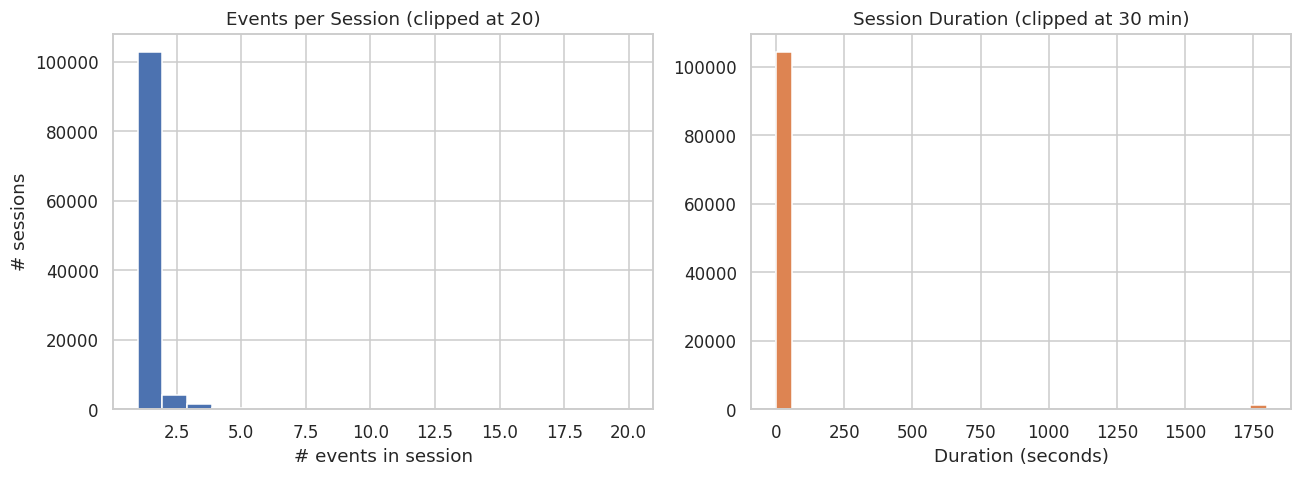

Single-event sessions: 93.8%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(sessions["n_events"].clip(upper=20), bins=20, color="#4C72B0")
axes[0].set_title("Events per Session (clipped at 20)")
axes[0].set_xlabel("# events in session")
axes[0].set_ylabel("# sessions")

axes[1].hist(sessions["duration_sec"].clip(upper=1800), bins=30, color="#DD8452")
axes[1].set_title("Session Duration (clipped at 30 min)")
axes[1].set_xlabel("Duration (seconds)")

plt.tight_layout()
plt.savefig(FE_ASSETS / "01_session_distributions.png", bbox_inches="tight")
plt.show()

single_event_sessions = (sessions["n_events"] == 1).mean()
print(f"Single-event sessions: {single_event_sessions:.1%}")


## 4. Item Properties: From Event-Log Format to One Row per Item

`item_properties` is a time-varying "EAV" log — one row per
`(item, property, time the property changed)`. For recommendation
purposes we want the CURRENT state of each product, so we take the latest
value per `(item, property)` and pivot to a wide table.

We extract `categoryid`, `available`, and the hashed numeric property
`'790'` (price) — the properties this project's models actually use.
Retailrocket's real file has dozens of additional hashed properties with
no documented meaning; carrying their full cardinality forward would add
noise, not signal.


In [6]:
item_attributes = prep.clean_item_properties(item_properties_raw)
display(item_attributes.head())

print(f"\nItems missing category: {(~item_attributes['has_category']).sum()} "
      f"({(~item_attributes['has_category']).mean():.1%})")
print(f"Items missing price: {(~item_attributes['has_price']).sum()} "
      f"({(~item_attributes['has_price']).mean():.1%})")
print(f"Items with availability defaulted to 1 (unknown -> assumed recommendable): "
      f"see preprocessing log for exact count")


2026-07-25 06:26:50 | INFO     | src.preprocessing | clean_item_properties: 3000 items | missing category: 14 | missing price: 16 | missing availability (defaulted to available=1): 10


2026-07-25 06:26:50 | INFO     | src.preprocessing | clean_item_properties completed in 0.02s


,itemid,available,categoryid,has_category,price,has_price
0,1,1,1033.0,True,39146.0,True
1,2,1,1060.0,True,28652.0,True
2,3,1,1029.0,True,6169.0,True
3,4,1,1078.0,True,23819.0,True
4,5,1,1009.0,True,38367.0,True



Items missing category: 14 (0.5%)
Items missing price: 16 (0.5%)
Items with availability defaulted to 1 (unknown -> assumed recommendable): see preprocessing log for exact count


## 5. Category Tree Cleaning

A `NaN` `parentid` is Retailrocket's convention for a root-level category
— not missing data. We make this explicit with an `is_root` flag.


In [7]:
category_tree_clean = prep.clean_category_tree(category_tree_raw)
display(category_tree_clean.head())
print(f"{category_tree_clean['is_root'].sum()} root categories, "
      f"{(~category_tree_clean['is_root']).sum()} child categories")


2026-07-25 06:26:50 | INFO     | src.preprocessing | clean_category_tree: 120 categories (10 root, 110 child)


2026-07-25 06:26:50 | INFO     | src.preprocessing | clean_category_tree completed in 0.00s


,categoryid,parentid,is_root
0,1000,NaN,True
1,1001,NaN,True
2,1002,NaN,True
3,1003,NaN,True
4,1004,NaN,True


10 root categories, 110 child categories


## 6. Feature Engineering: Category Features

Built first because item features use `category_popularity_score` as a
smoothed prior for products with too little individual signal.


In [8]:
item_categories = item_attributes[["itemid", "categoryid"]]
category_features = fe.build_category_features(events_with_sessions, item_categories)
display(category_features.sort_values("total_interactions", ascending=False).head(10))


2026-07-25 06:26:50 | INFO     | src.feature_engineering | build_category_features: 120 categories


2026-07-25 06:26:50 | INFO     | src.feature_engineering | build_category_features completed in 0.05s


,categoryid,category_view_count,category_addtocart_count,category_transaction_count,total_interactions,num_items_in_category,category_popularity_score
33,1033.0,46514,5688,2566,54768,30,1.000000
60,1060.0,15719,1942,865,18526,25,1.000000
29,1029.0,7945,1025,404,9374,38,0.557904
78,1078.0,4887,601,323,5811,26,0.345417
9,1009.0,3537,409,211,4157,27,0.246778
67,1067.0,2611,324,166,3101,29,0.183801
95,1095.0,2022,229,117,2368,24,0.140087
41,1041.0,1625,217,108,1950,29,0.115159
4,1004.0,1200,146,78,1424,25,0.083790
102,1102.0,1065,135,59,1259,25,0.073950


## 7. Feature Engineering: User Features



In [9]:
user_features = fe.build_user_features(events_with_sessions, sessions, item_categories)
display(user_features.head())
print(f"\n{len(user_features):,} users x {user_features.shape[1]} features")


2026-07-25 06:26:50 | INFO     | src.feature_engineering | build_user_features: 3999 users, 15 features


2026-07-25 06:26:50 | INFO     | src.feature_engineering | build_user_features completed in 0.12s


,visitorid,user_view_count,user_addtocart_count,user_purchase_count,unique_items_viewed,unique_categories_viewed,first_seen,last_seen,n_sessions,avg_session_duration_sec,median_session_duration_sec,activity_score_raw,recency_days,conversion_rate_user,click_to_purchase_ratio_user,user_activity_score
0,1,10,1,0,6,6,2015-05-05 00:02:24,2015-08-27 02:07:53,11,0.0,0.0,2.109203,3.909919,0.000000,0.0,0.035181
1,2,3,1,1,5,4,2015-05-25 04:58:39,2015-08-23 12:14:20,5,0.0,0.0,0.820123,7.488773,0.333333,1.0,0.013643
2,3,24,4,2,10,10,2015-05-13 07:19:04,2015-08-19 14:21:06,30,0.0,0.0,7.031930,11.400741,0.083333,0.5,0.117433
3,4,5,0,1,3,3,2015-06-01 06:24:01,2015-07-25 10:44:27,6,0.0,0.0,0.536148,36.551192,0.200000,0.0,0.008898
4,5,5,1,0,4,4,2015-05-17 22:58:45,2015-08-30 04:16:36,6,0.0,0.0,2.123775,0.820532,0.000000,0.0,0.035425



3,999 users x 16 features


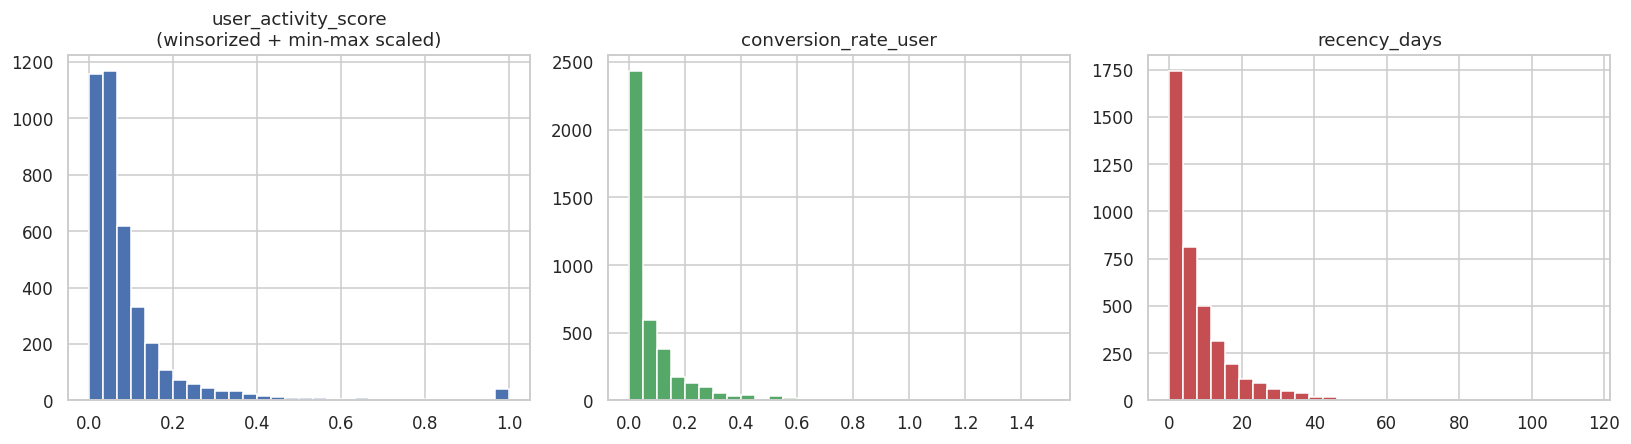

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].hist(user_features["user_activity_score"], bins=30, color="#4C72B0")
axes[0].set_title("user_activity_score\n(winsorized + min-max scaled)")

axes[1].hist(user_features["conversion_rate_user"], bins=30, color="#55A868")
axes[1].set_title("conversion_rate_user")

axes[2].hist(user_features["recency_days"], bins=30, color="#C44E52")
axes[2].set_title("recency_days")

plt.tight_layout()
plt.savefig(FE_ASSETS / "02_user_feature_distributions.png", bbox_inches="tight")
plt.show()


**Why winsorize before scaling — shown, not just claimed:** below is the
raw activity score (heavy right tail, expected given Phase 1's power-law
finding) next to the winsorized+scaled version. Without capping, one or two
extreme users would compress everyone else's score toward 0.


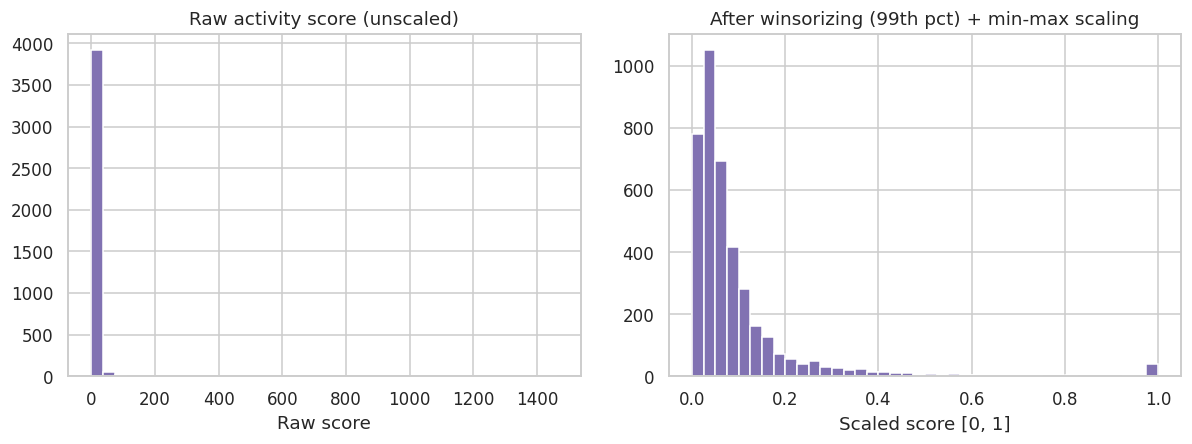

40 users (1.00%) were capped at the 99th percentile (59.85)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(user_features["activity_score_raw"], bins=40, color="#8172B2")
axes[0].set_title("Raw activity score (unscaled)")
axes[0].set_xlabel("Raw score")

axes[1].hist(user_features["user_activity_score"], bins=40, color="#8172B2")
axes[1].set_title("After winsorizing (99th pct) + min-max scaling")
axes[1].set_xlabel("Scaled score [0, 1]")

plt.tight_layout()
plt.savefig(FE_ASSETS / "03_winsorize_before_after.png", bbox_inches="tight")
plt.show()

p99 = user_features["activity_score_raw"].quantile(0.99)
n_capped = (user_features["activity_score_raw"] > p99).sum()
print(f"{n_capped} users ({n_capped/len(user_features):.2%}) were capped at the 99th percentile ({p99:.2f})")


## 8. Feature Engineering: Item Features

Built starting from the FULL item catalog (`item_attributes`), not just
items that happen to appear in `events` — items with zero interactions are
exactly the cold-start products this system needs to handle explicitly
(via `is_cold_start`), not silently drop from the feature table.


In [12]:
item_features = fe.build_item_features(events_with_sessions, item_attributes, category_features)
display(item_features.head())

n_cold = item_features["is_cold_start"].sum()
print(f"\n{len(item_features):,} items x {item_features.shape[1]} features")
print(f"Cold-start items (zero interactions): {n_cold:,} ({n_cold/len(item_features):.1%} of catalog)")


2026-07-25 06:26:51 | INFO     | src.feature_engineering | build_item_features: 3000 items (1086 cold-start / zero interactions)


2026-07-25 06:26:51 | INFO     | src.feature_engineering | build_item_features completed in 0.08s


,itemid,available,categoryid,has_category,price,has_price,item_view_count,item_addtocart_count,item_transaction_count,unique_visitors,last_seen,interaction_score_raw,is_cold_start,recency_days,product_conversion_rate,click_to_purchase_ratio_item,product_interaction_score,popularity_rank,category_popularity_score
0,1,1,1033.0,True,39146.0,True,45120.0,5538.0,1806.0,3971.0,2015-08-30 23:58:10,11810.104282,False,0.000000,0.040027,0.326111,1.0,1,1.000000
1,2,1,1060.0,True,28652.0,True,14945.0,1837.0,573.0,3470.0,2015-08-30 23:52:36,3961.136553,False,0.003866,0.038341,0.311922,1.0,2,1.000000
2,3,1,1029.0,True,6169.0,True,7812.0,1006.0,287.0,2775.0,2015-08-30 23:39:17,2109.350218,False,0.013113,0.036738,0.285288,1.0,3,0.557904
3,4,1,1078.0,True,23819.0,True,4854.0,599.0,229.0,2157.0,2015-08-30 23:54:17,1306.535570,False,0.002697,0.047178,0.382304,1.0,4,0.345417
4,5,1,1009.0,True,38367.0,True,3478.0,400.0,145.0,1784.0,2015-08-30 23:50:34,888.394608,False,0.005278,0.041691,0.362500,1.0,5,0.246778



3,000 items x 19 features
Cold-start items (zero interactions): 1,086 (36.2% of catalog)


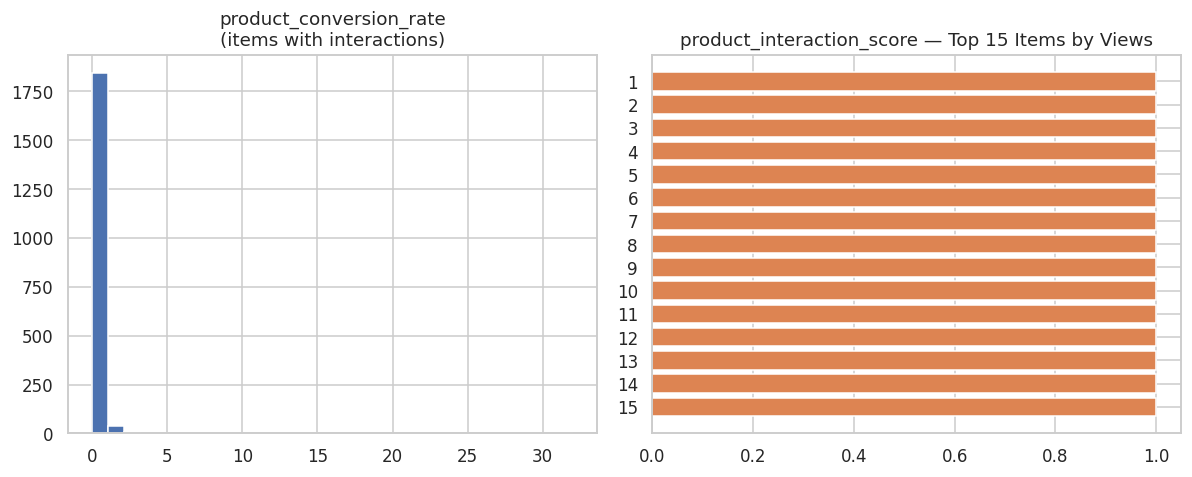

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(item_features.loc[~item_features["is_cold_start"], "product_conversion_rate"], bins=30, color="#4C72B0")
axes[0].set_title("product_conversion_rate\n(items with interactions)")

top_items = item_features.sort_values("item_view_count", ascending=False).head(15)
axes[1].barh(top_items["itemid"].astype(str), top_items["product_interaction_score"], color="#DD8452")
axes[1].set_title("product_interaction_score — Top 15 Items by Views")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FE_ASSETS / "04_item_feature_distributions.png", bbox_inches="tight")
plt.show()


**Business read:** `is_cold_start` gives an exact, queryable count of
"products the popularity/collaborative signal cannot rank at all" — this
number is precisely why Phase 3 needs a content-based model (which can
recommend a product on its category/attributes alone, with zero
interaction history) rather than relying on collaborative filtering or
popularity as the only strategy.


## 9. Feature Table Summary & Persistence

All three tables are persisted to `data/processed/` as Parquet (typed,
compressed, fast to reload — unlike re-parsing CSV on every run). Phase 3
models load directly from these files via `src.config.PROCESSED_FILES`.


In [14]:
summary = pd.DataFrame({
    "table": ["user_features", "item_features", "category_features"],
    "rows": [len(user_features), len(item_features), len(category_features)],
    "columns": [user_features.shape[1], item_features.shape[1], category_features.shape[1]],
})
display(summary)


,table,rows,columns
0,user_features,3999,16
1,item_features,3000,19
2,category_features,120,7


## 10. Summary of Phase 2 Decisions

- **Deduplication** removes only exact duplicate rows — preserves every
  genuine repeat interaction.
- **ID encoding** produces contiguous `user_idx`/`item_idx` for Phase 3's
  sparse matrices, with the original-ID mapping persisted for inference.
- **Sessions** use a defensible, industry-standard 30-minute cutoff rather
  than an arbitrary threshold.
- **Item properties** are collapsed from a change-log to current-state,
  with missing category/price/availability each handled with an explicit,
  justified rule — never a blanket `fillna(0)`.
- **Outlier handling** follows directly from Phase 1: cap (winsorize),
  don't drop, when a raw count feeds into a composite score.
- **Cold-start items** are tracked explicitly (`is_cold_start`), not
  silently dropped from the item feature table — Phase 3 needs to know
  exactly which products collaborative filtering and popularity ranking
  cannot serve.

Next: **Phase 3 — Recommendation Models** (popularity-based, content-based
TF-IDF/cosine similarity, collaborative filtering — user-based, item-based,
and SVD — and a hybrid combiner), built directly on top of
`user_features`, `item_features`, and `category_features`.
